WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


Instalação concluída silenciosamente.


WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, beta, taxa]


Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 33 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha  0.705  0.265   0.291    1.236      0.005    0.003    2762.0    2860.0   
beta   3.921  1.879   1.007    7.444      0.032    0.023    3233.0    2933.0   

       r_hat  
alpha    1.0  
beta     1.0  


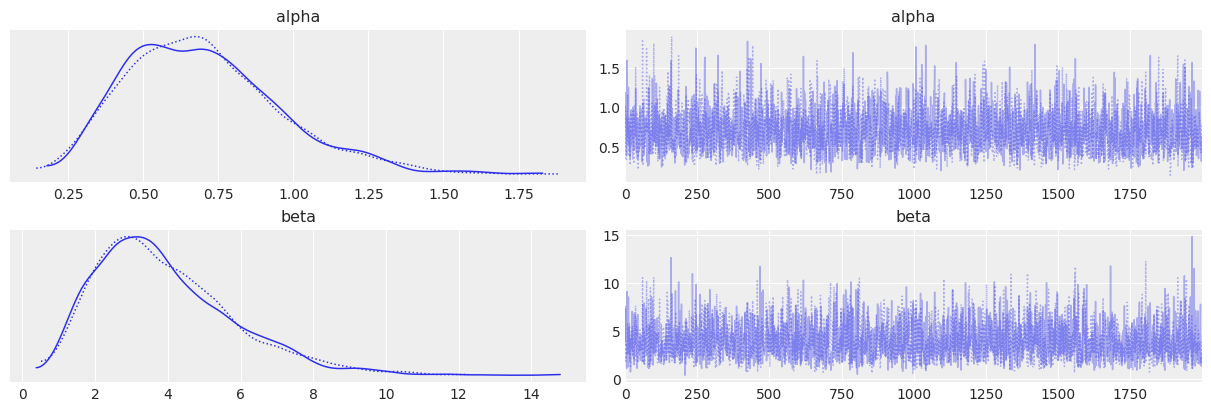

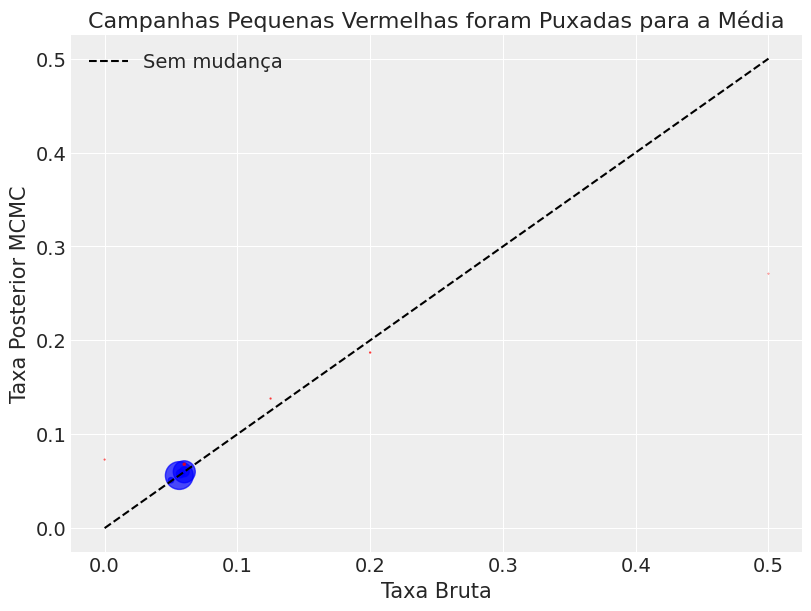

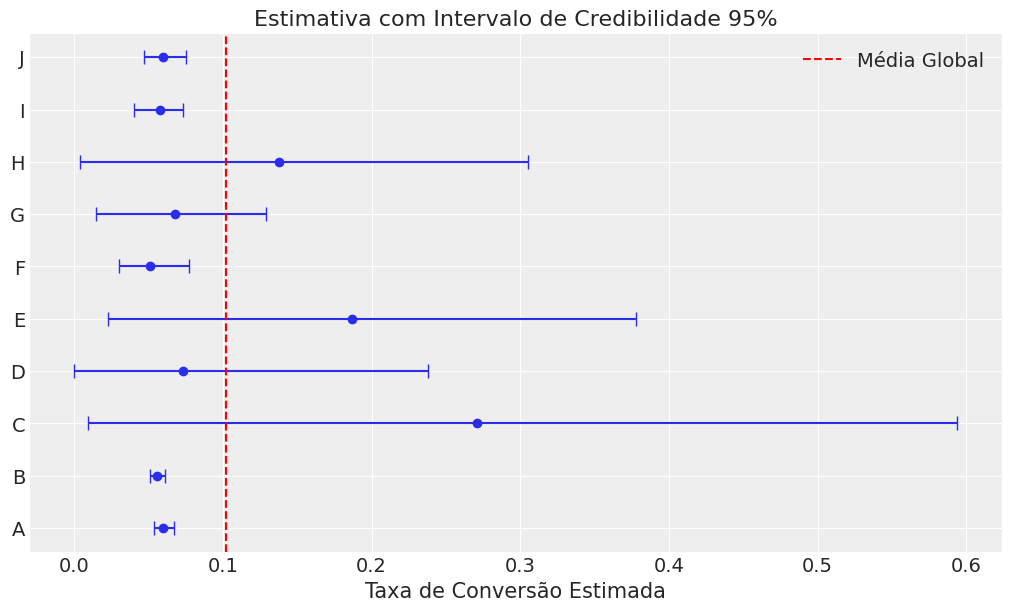

Campanha  impressoes  taxa_bruta  taxa_mcmc  P_melhor_que_media                       Ação
       C           2       0.500      0.271                0.82                    ESCALAR
       E          10       0.200      0.187                0.78 MANTER E COLETAR MAIS DADO
       H           8       0.125      0.138                0.57 MANTER E COLETAR MAIS DADO
       D           5       0.000      0.073                0.25 MANTER E COLETAR MAIS DADO
       G          50       0.060      0.068                0.15                     PAUSAR
       A        5000       0.060      0.060                0.00                     PAUSAR
       B        8000       0.056      0.056                0.00                     PAUSAR
       F         300       0.050      0.051                0.00                     PAUSAR
       I         700       0.057      0.058                0.00                     PAUSAR
       J        1000       0.060      0.060                0.00                     PAUSAR

In [8]:
# ------------------0. SETUP--------------------------
import sys
import subprocess

# Lista de pacotes para instalar
pacotes = ['pymc', 'arviz', 'matplotlib']

# O parâmetro "-q" (ou "--quiet") reduz a saída do log no console
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pacotes)

print("Instalação concluída silenciosamente.")
import pymc as pm
import arviz as az
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
az.style.use("arviz-darkgrid")
#--------------------------------------1. O PROBLEMA DE NEGÓCIO----------------------------------------------------------
# Gestor de tráfego tem 10 campanhas. Orçamento é limitado. 
# Se pausar campanha por causa de ruído nos primeiros dias, joga dinheiro fora.
# Se escalar campanha ruim por sorte, também joga dinheiro fora.

# Taxa bruta = `cliques / impressoes` é instável com pouco dado.
# Dados simulados
df = pd.DataFrame({
    'Campanha': ['A','B','C','D','E','F','G','H','I','J'],
    'cliques': [300, 450, 1, 0, 2, 15, 3, 1, 40, 60],
    'impressoes': [5000,8000, 2, 5, 10, 300, 50, 8, 700,1000]
})
df['taxa_bruta'] = df['cliques'] / df['impressoes']
df
# -------------------------------------2. O MODELO: Beta-Binomial Hierárquico---------------------------------------------
# Ideia: Todas campanhas vêm de uma "taxa média da conta". Campanhas pequenas são puxadas pra essa média.
with pm.Model() as modelo_ads:
    # Hiperpriors: aprendem qual é a taxa típica da conta
    alpha = pm.Exponential('alpha', 1.0)
    beta = pm.Exponential('beta', 1.0)
    
    # Cada campanha tem sua taxa
    taxa = pm.Beta('taxa', alpha=alpha, beta=beta, shape=len(df))
    
    # Dados
    obs = pm.Binomial('obs', n=df['impressoes'], p=taxa, observed=df['cliques'])
    
    # Amostragem MCMC
    trace = pm.sample(2000, tune=1000, target_accept=0.9, cores=2, random_seed=42)
    
# Checagem de convergência
print(az.summary(trace, var_names=['alpha','beta']))
az.plot_trace(trace, var_names=['alpha','beta'])
#-----------------------------------------3. RESULTADO + VISUALIZAÇÃO--------------------------------------------------------
#Aqui está a mágica: "Encolhimento"
#Junta resultados
resumo = az.summary(trace, var_names=['taxa'])
df['taxa_mcmc'] = resumo['mean'].values
df['ic_low'] = resumo['hdi_3%'].values
df['ic_high'] = resumo['hdi_97%'].values

#----------------------------------------------GRÁFICO 1: Efeito de Encolhimento--------------------------------------------
plt.figure(figsize=(8,6))
cores = np.where(df['impressoes'] < 100, 'red', 'blue')
plt.scatter(df['taxa_bruta'], df['taxa_mcmc'], s=df['impressoes']/20, c=cores, alpha=0.7)
plt.plot([0, 0.5], [0, 0.5], 'k--', label='Sem mudança')
plt.xlabel('Taxa Bruta')
plt.ylabel('Taxa Posterior MCMC')
plt.title('Campanhas Pequenas Vermelhas foram Puxadas para a Média')
plt.legend()
plt.grid(True)
plt.show()
# Interpretação: Bolinhas vermelhas pequenas foram "puxadas" pra ∼6%. Bolinhas azuis grandes ficaram iguais.
# GRÁFICO 2: Incerteza por Campanha
plt.figure(figsize=(10,6))
y_pos = np.arange(len(df))
plt.errorbar(df['taxa_mcmc'], y_pos, xerr=[df['taxa_mcmc']-df['ic_low'], df['ic_high']-df['taxa_mcmc']], 
             fmt='o', capsize=5)
plt.yticks(y_pos, df['Campanha'])
plt.xlabel('Taxa de Conversão Estimada')
plt.title('Estimativa com Intervalo de Credibilidade 95%')
plt.axvline(df['taxa_mcmc'].mean(), color='r', linestyle='--', label='Média Global')
plt.legend()
plt.show()
# ---------------------------------------------
# 4. DECISÃO DE NEGÓCIO - RELATÓRIO FINAL
# ---------------------------------------------

# Calculando a média global do posterior
media_global = df['taxa_mcmc'].mean()

# Calculando a probabilidade de cada campanha ser superior à média
prob_melhor = (trace.posterior['taxa'].values > media_global).mean(axis=(0, 1))
df['P_melhor_que_media'] = prob_melhor

# Definindo as regras de decisão
df['Ação'] = np.select(
    [df['P_melhor_que_media'] > 0.8, df['P_melhor_que_media'] < 0.2],
    ['ESCALAR', 'PAUSAR'],
    default='MANTER E COLETAR MAIS DADO'
)

# Seleção e formatação do relatório final
relatorio = df[['Campanha', 'impressoes', 'taxa_bruta', 'taxa_mcmc', 'P_melhor_que_media', 'Ação']].copy()

# Ajuste de casas decimais para melhor leitura
relatorio['taxa_bruta'] = relatorio['taxa_bruta'].round(3)
relatorio['taxa_mcmc'] = relatorio['taxa_mcmc'].round(3)
relatorio['P_melhor_que_media'] = relatorio['P_melhor_que_media'].round(2)

# Exibindo ordenado pela maior probabilidade de ser "vencedora"
print(relatorio.sort_values('P_melhor_que_media', ascending=False).to_string(index=False))
#-------------------------------------------5. CONCLUSÃO-------------------------------------------------
#*Impacto*: Com taxa bruta, teríamos pausado D e escalado C errado. Com MCMC, esperamos mais dados.  
#*Stack*: PyMC para modelagem, Arviz para diagnóstico, abordagem Bayesiana para incerteza.  
#*Próximo passo*: Rodar isso diário e plugar no otimizador de budget.

No contexto do seu modelo Bayesiano, P_melhor_que_media representa a probabilidade posterior de que a taxa de conversão real daquela campanha seja maior do que a taxa média de todas as suas campanhas juntas.